# RevRate - Analiza danych (EDA)

## Importy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

## Wczytanie danych

In [2]:
from pathlib import Path

csv_path = Path("../data/Car_sale_ads.csv")
if not csv_path.exists():
    print("Plik nie istnieje. Uruchamianie download_dataset.py...")
    import subprocess
    subprocess.run(["py", "../src/revrate/download_dataset.py"], check=True)

df = pd.read_csv(csv_path)
print("Opis kolumn:\n")
df.info()
print("\n\nOpis statystyczny danych:\n")
df.describe()

Plik nie istnieje. Uruchamianie download_dataset.py...
Opis kolumn:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208304 entries, 0 to 208303
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    208304 non-null  int64  
 1   Price                    208304 non-null  int64  
 2   Currency                 208304 non-null  object 
 3   Condition                208304 non-null  object 
 4   Vehicle_brand            208304 non-null  object 
 5   Vehicle_model            208304 non-null  object 
 6   Vehicle_version          138082 non-null  object 
 7   Vehicle_generation       147860 non-null  object 
 8   Production_year          208304 non-null  int64  
 9   Mileage_km               207321 non-null  float64
 10  Power_HP                 207661 non-null  float64
 11  Displacement_cm3         206338 non-null  float64
 12  Fuel_type                208304 non-null  obj

,Index,Price,Production_year,Mileage_km,Power_HP,Displacement_cm3,CO2_emissions,Doors_number
count,208304.000000,2.083040e+05,208304.000000,2.073210e+05,207661.000000,206338.000000,9.404700e+04,206817.000000
mean,104151.500000,6.305383e+04,2012.098241,1.502768e+05,151.836281,1882.567147,3.191564e+05,4.637138
std,60132.329574,8.665967e+04,6.998414,2.937447e+06,77.683546,729.609660,7.291396e+07,0.768559
min,0.000000,5.000000e+02,1915.000000,1.000000e+00,1.000000,400.000000,1.000000e+00,1.000000
25%,52075.750000,1.780000e+04,2008.000000,5.300000e+04,105.000000,1461.000000,1.200000e+02,5.000000
50%,104151.500000,3.570000e+04,2013.000000,1.445660e+05,136.000000,1798.000000,1.400000e+02,5.000000
75%,156227.250000,7.599000e+04,2017.000000,2.060000e+05,172.000000,1997.000000,1.640000e+02,5.000000
max,208303.000000,6.999000e+06,2021.000000,1.111111e+09,1398.000000,8400.000000,2.000000e+10,55.000000


## Analiza brakow danych

In [3]:
def suggest_action(missing_pct, unique_count, total_rows):
    if unique_count <= 1:
        return 'UNIQUE'
    if unique_count >= total_rows * 0.95:
        return 'ID-LIKE'
    if missing_pct > 25:
        return 'DROP'
    if missing_pct < 25:
        return 'KEEP'
    return 'IMPUTUJ'

summary = pd.DataFrame({
    'braki': df.isnull().sum(),
    '%': (df.isnull().sum() / len(df) * 100).round(1),
    'unikalne': df.nunique(),
})
total = len(df)
summary['rezultat'] = [
    suggest_action(row['%'], row['unikalne'], total)
    for _, row in summary.iterrows()
]
print(summary.sort_values('braki', ascending=False))

                          braki     %  unikalne rezultat
First_owner              143210  68.8         1   UNIQUE
First_registration_date  121859  58.5      8441     DROP
CO2_emissions            114257  54.9       372     DROP
Origin_country            89992  43.2        37     DROP
Vehicle_version           70222  33.7     19056     DROP
Vehicle_generation        60444  29.0       569     DROP
Drive                     15076   7.2         5     KEEP
Displacement_cm3           1966   0.9      1181     KEEP
Doors_number               1487   0.7        10     KEEP
Mileage_km                  983   0.5     52007     KEEP
Power_HP                    643   0.3       573     KEEP
Transmission                479   0.2         2     KEEP
Condition                     0   0.0         2     KEEP
Currency                      0   0.0         2     KEEP
Price                         0   0.0     14142     KEEP
Index                         0   0.0    208304  ID-LIKE
Vehicle_brand                 0

## Rozklady zmiennych

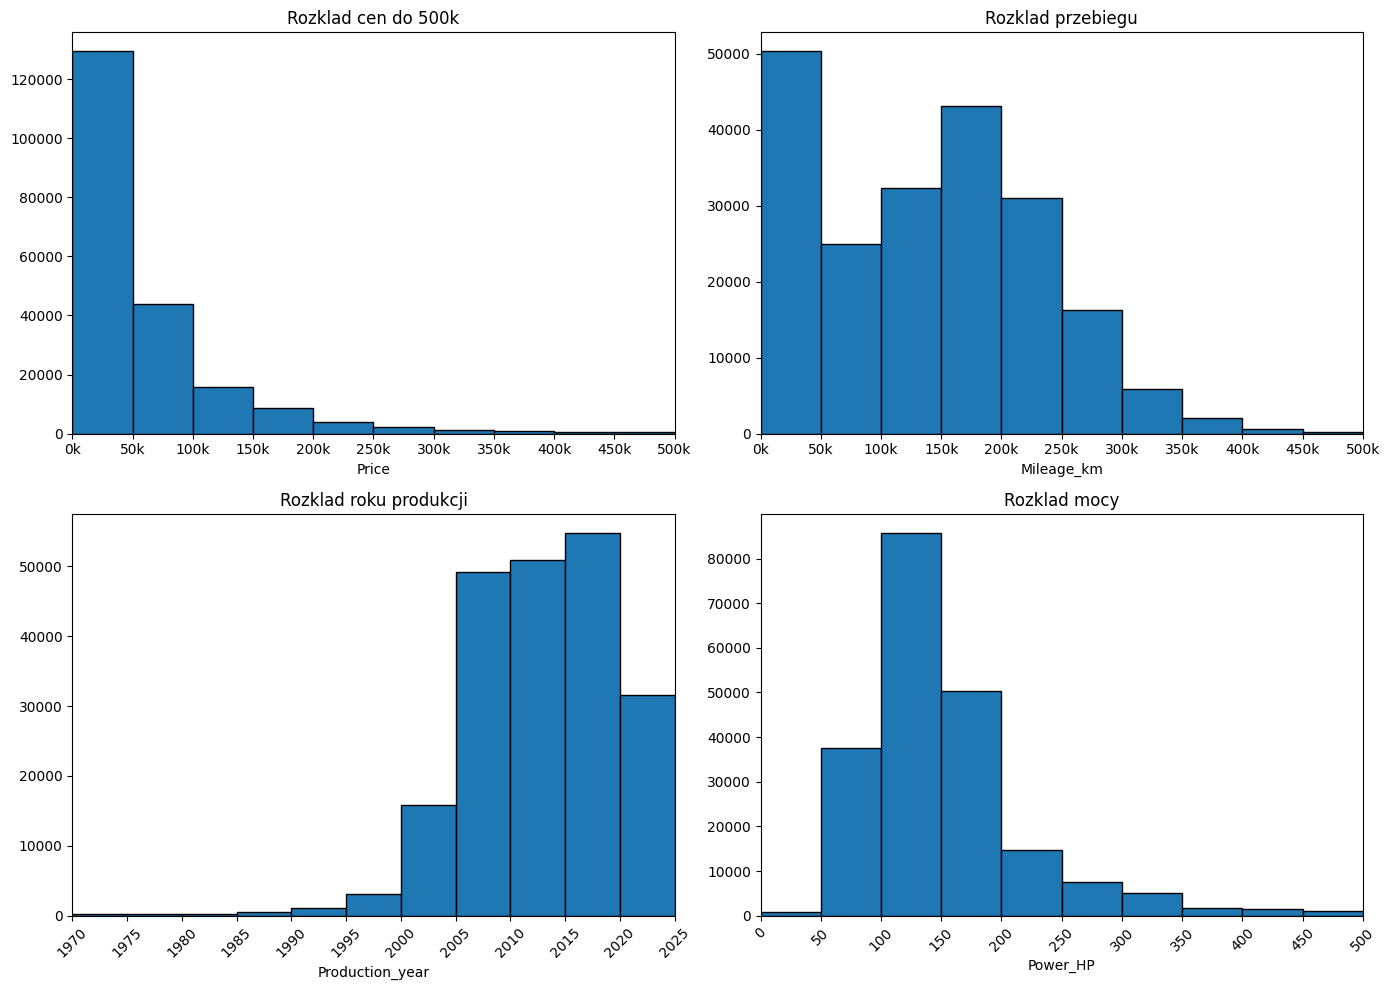

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['Price'].dropna(), bins=10, range=(0, 500000), edgecolor='black')
axes[0,0].set_xlim(0, 500000)
axes[0,0].set_xticks(range(0, 500001, 50000))
axes[0,0].set_xticklabels([str(int(t/1000)) + 'k' for t in range(0, 500001, 50000)])
axes[0,0].set_title('Rozklad cen do 500k')
axes[0,0].set_xlabel('Price')

axes[0,1].hist(df['Mileage_km'].dropna(), bins=10, range=(0, 500000), edgecolor='black')
axes[0,1].set_xlim(0, 500000)
axes[0,1].set_xticks(range(0, 500001, 50000))
axes[0,1].set_xticklabels([str(int(t/1000)) + 'k' for t in range(0, 500001, 50000)])
axes[0,1].set_title('Rozklad przebiegu')
axes[0,1].set_xlabel('Mileage_km')

axes[1,0].hist(df['Production_year'].dropna(), bins=11, range=(1970, 2025), edgecolor='black')
axes[1,0].set_xlim(1970, 2025)
axes[1,0].set_xticks(range(1970, 2026, 5))
axes[1,0].set_xticklabels([str(t) for t in range(1970, 2026, 5)], rotation=45)
axes[1,0].set_title('Rozklad roku produkcji')
axes[1,0].set_xlabel('Production_year')

axes[1,1].hist(df['Power_HP'].dropna(), bins=10, range=(0, 500), edgecolor='black')
axes[1,1].set_xlim(0, 500)
axes[1,1].set_xticks(range(0, 501, 50))
axes[1,1].set_xticklabels([str(t) for t in range(0, 501, 50)], rotation=45)
axes[1,1].set_title('Rozklad mocy')
axes[1,1].set_xlabel('Power_HP')

plt.tight_layout()
plt.show()

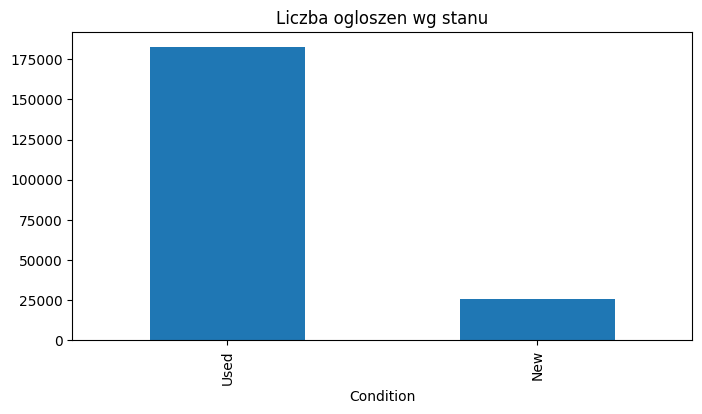

In [5]:
df['Condition'].value_counts().plot(kind='bar', figsize=(8,4), title='Liczba ogloszen wg stanu')
plt.show()

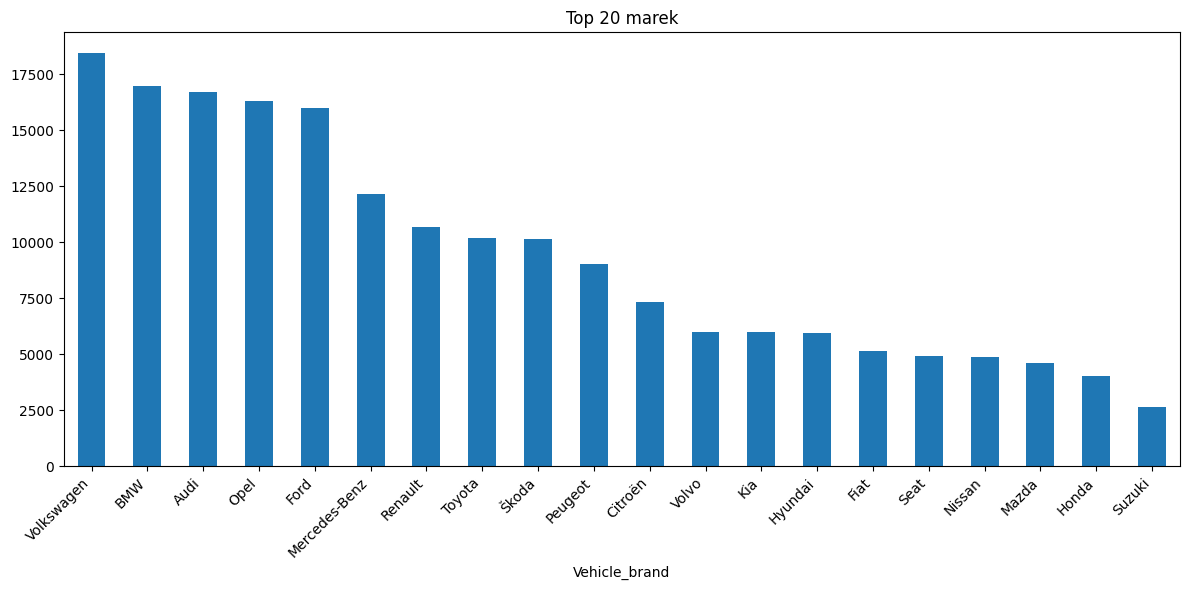

In [6]:
top_brands = df['Vehicle_brand'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12,6))
top_brands.plot(kind='bar', ax=ax)
ax.set_title('Top 20 marek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

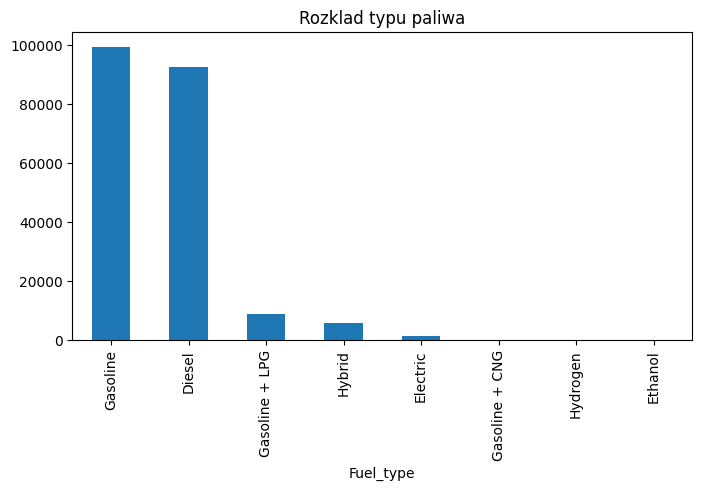

In [7]:
df['Fuel_type'].value_counts().plot(kind='bar', figsize=(8,4), title='Rozklad typu paliwa')
plt.show()

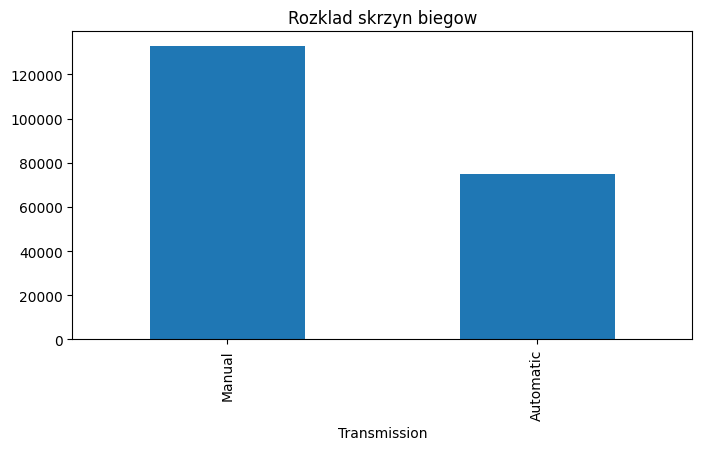

In [8]:
df['Transmission'].value_counts().plot(kind='bar', figsize=(8,4), title='Rozklad skrzyn biegow')
plt.show()

In [9]:
df['Currency'].value_counts()

Currency
PLN    208034
EUR       270
Name: count, dtype: int64

## Korelacja z cena

In [10]:
corr_cols = df.select_dtypes(include=[np.number]).columns
corr = df[corr_cols].corr()['Price'].sort_values(ascending=False)
print('Korelacja z cena:')
print(corr)

Korelacja z cena:
Price               1.000000
Power_HP            0.641298
Production_year     0.441425
Displacement_cm3    0.362415
CO2_emissions      -0.001300
Mileage_km         -0.017602
Doors_number       -0.034275
Index              -0.106673
Name: Price, dtype: float64
